In [1]:
!pip install tensorflow requests -q

Loading category: Face
  Success: https://images.pexels.com/photos/774909/pexels-photo-774909.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
  Success: https://images.pexels.com/photos/1043471/pexels-photo-1043471.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
  Success: https://images.pexels.com/photos/91227/pexels-photo-91227.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
Loading category: Car
  Success: https://images.pexels.com/photos/112460/pexels-photo-112460.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
  Success: https://images.pexels.com/photos/170811/pexels-photo-170811.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
  Success: https://images.pexels.com/photos/707046/pexels-photo-707046.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
Loading category: Flower
  Success: https://images.pexels.com/photos/36729/tulip-flower-bloom-pink.jpg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
  Success: https://images.pexels.com/photos/132474/pexels-photo-132474.jpeg?auto=

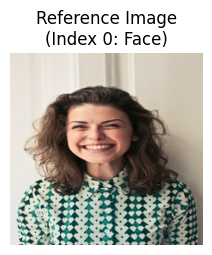

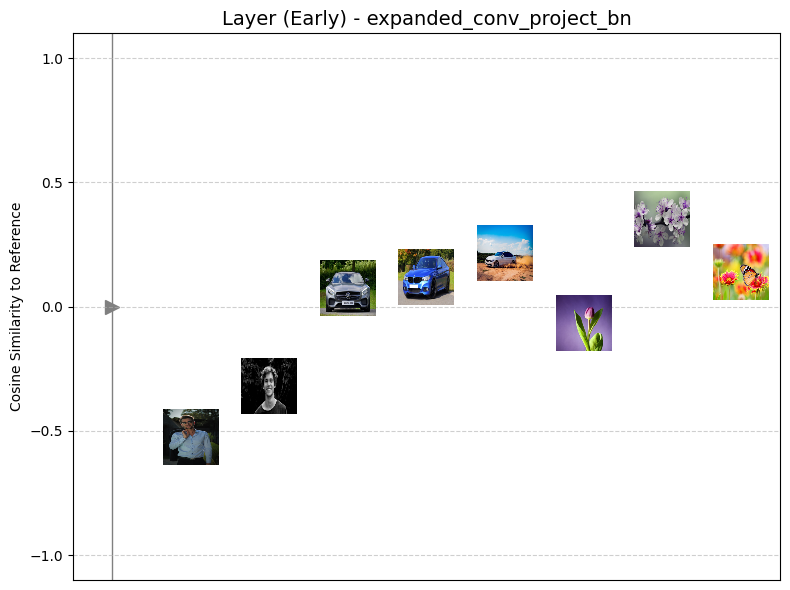

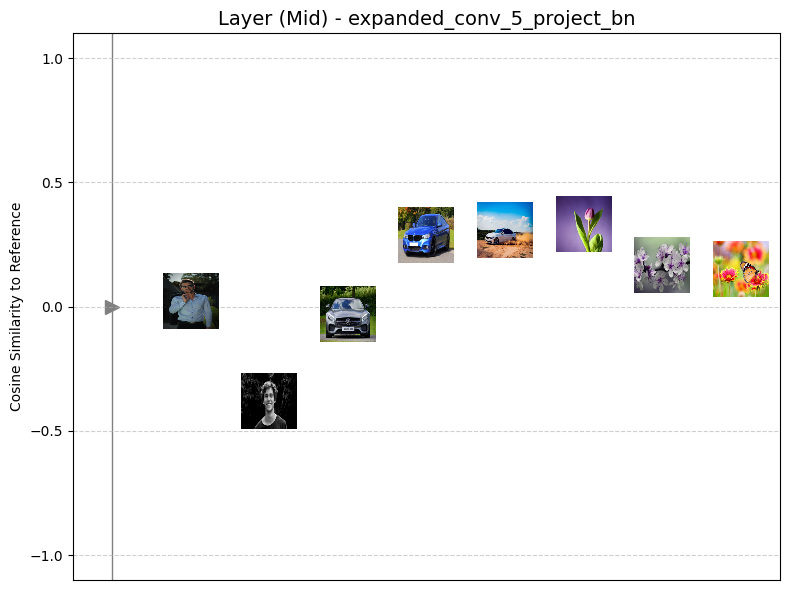

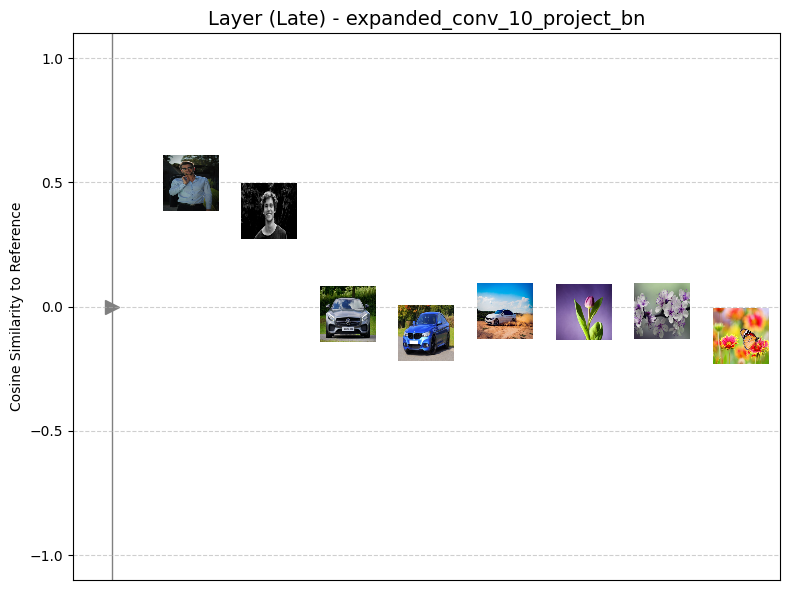


Visualization complete.


In [2]:
# -*- coding: utf-8 -*-
"""
基準画像との類似度に基づく画像配置デモ（縦軸・個別Figure版）

少数の画像（顔、車、花）を使い、MobileNetV3-Smallの
初期・中間・最終層での特徴ベクトルを抽出。
最初の画像（基準画像）と他の画像とのコサイン類似度を計算し、
その類似度スコアを縦軸に対応させて画像を配置。
各レイヤーの結果を個別のFigureに表示します。
"""

# --- 0. ライブラリのインストール & インポート ---
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from matplotlib.offsetbox import OffsetImage, AnnotationBbox # 画像をプロット上に配置するために必要

# --- 1. パラメータ設定 ---
# (前回と同じ)
img_height, img_width = 224, 224
image_urls = {
    'Face': [
        "https://images.pexels.com/photos/774909/pexels-photo-774909.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1",
        "https://images.pexels.com/photos/1043471/pexels-photo-1043471.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1",
        "https://images.pexels.com/photos/91227/pexels-photo-91227.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1"
    ], 'Car': [
        "https://images.pexels.com/photos/112460/pexels-photo-112460.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1",
        "https://images.pexels.com/photos/170811/pexels-photo-170811.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1",
        "https://images.pexels.com/photos/707046/pexels-photo-707046.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1"
    ], 'Flower': [
        "https://images.pexels.com/photos/36729/tulip-flower-bloom-pink.jpg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1",
        "https://images.pexels.com/photos/132474/pexels-photo-132474.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1",
        "https://images.pexels.com/photos/462118/pexels-photo-462118.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1"
    ]
}
# ★用語変更 & 辞書キーも変更★
layer_names = {
    'Early': 'expanded_conv_project_bn',
    'Mid':   'expanded_conv_5_project_bn',
    'Late':  'expanded_conv_10_project_bn'
}
layer_keys_in_order = ['Early', 'Mid', 'Late'] # 処理と表示の順序を定義
category_order = ['Face', 'Car', 'Flower']
# カテゴリの色分け (線用)
category_colors = {
    'Face': 'red',
    'Car': 'blue',
    'Flower': 'green'
}

# --- 2. 画像の準備 ---
# (前回と同じ)
print("Downloading and preprocessing images...")
input_images_preprocessed = []
original_images_for_display = []
labels = []
category_counts = {cat: 0 for cat in category_order}
current_index = 0
for category in category_order:
    urls = image_urls[category]
    print(f"Loading category: {category}")
    for url in urls:
        try:
            headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
            response = requests.get(url, headers=headers, timeout=10); response.raise_for_status()
            img = Image.open(BytesIO(response.content)).convert('RGB')
            img_resized = img.resize((img_width, img_height))
            original_images_for_display.append(img_resized)
            img_array = tf.keras.preprocessing.image.img_to_array(img_resized)
            img_array_expanded = np.expand_dims(img_array, axis=0)
            img_preprocessed = preprocess_input(img_array_expanded)
            input_images_preprocessed.append(img_preprocessed)
            labels.append(category)
            category_counts[category] += 1
            current_index += 1
            print(f"  Success: {url}")
        except requests.exceptions.RequestException as e: print(f"  Warning: Failed to load image {url}: {e}")
        except Exception as e: print(f"  Warning: Error processing image {url}: {e}")
if not input_images_preprocessed: raise ValueError("No images loaded.")
input_images = np.vstack(input_images_preprocessed)
num_total_images = len(labels)
print(f"\n{num_total_images} images loaded successfully in total.")
print("Category counts:", category_counts)

# --- 3. モデルのロードと中間層モデルの準備 ---
print("\nLoading MobileNetV3-Small and preparing intermediate models...")
try:
    base_model = MobileNetV3Small(input_shape=(img_height, img_width, 3), weights='imagenet', include_top=False)
    intermediate_models = {}
    verified_layer_names = {}
    actual_layers = {layer.name: layer for layer in base_model.layers}
    # ★layer_keys_in_order を使用★
    for layer_key in layer_keys_in_order:
        name = layer_names[layer_key]
        if name in actual_layers:
            layer_output = actual_layers[name].output
            pooled_output = GlobalAveragePooling2D()(layer_output)
            intermediate_models[layer_key] = Model(inputs=base_model.input, outputs=pooled_output)
            verified_layer_names[layer_key] = name
            print(f" - Layer ({layer_key}) model created using layer '{name}'")
        else: print(f" - Warning: Layer '{name}' for Layer ({layer_key}) not found. Skipping.")
    if not intermediate_models: raise ValueError("No valid intermediate models created.")
except Exception as e: print(f"Error loading model: {e}"); raise

# --- 4. 特徴抽出とコサイン類似度計算 ---
print("\nExtracting features and calculating similarities...")
similarity_matrices = {}
layers_processed = [] # 実際に処理できたレイヤーキー

# ★layer_keys_in_order を使用★
for layer_key in layer_keys_in_order:
    if layer_key in intermediate_models:
        model = intermediate_models[layer_key]
        layers_processed.append(layer_key)
        tf.get_logger().setLevel('ERROR'); features = model.predict(input_images); tf.get_logger().setLevel('WARNING')
        print(f" - Extracted features for Layer ({layer_key}), shape: {features.shape}")
        similarity_matrix = cosine_similarity(features)
        similarity_matrices[layer_key] = similarity_matrix
        print(f" - Cosine similarity matrix calculated for Layer ({layer_key}), shape: {similarity_matrix.shape}")

# --- 5. ★★★ 新しい可視化：類似度（縦軸）に基づいた画像配置（個別Figure版）★★★ ---
print("\nGenerating vertical similarity axis plots (separate figure for each layer)...")

num_layers_processed = len(layers_processed)
actual_num_images = num_total_images

if num_layers_processed > 0 and actual_num_images > 0:

    reference_image_index = 0
    reference_image = original_images_for_display[reference_image_index]
    reference_label = labels[reference_image_index]

    # 基準画像を最初に一度だけ表示
    fig_ref, ax_ref = plt.subplots(1, 1, figsize=(2.5, 2.5))
    ax_ref.imshow(reference_image)
    ax_ref.set_title(f"Reference Image\n(Index 0: {reference_label})")
    ax_ref.axis('off')
    plt.show() # 基準画像を表示

    # 各レイヤーごとに個別のFigureを作成
    for layer_key in layers_processed: # Early, Mid, Late の順
        if layer_key in similarity_matrices:

            # ★新しいFigureを作成★
            fig_sim_axis_v, ax = plt.subplots(1, 1, figsize=(8, 6)) # 各レイヤーに1つのAxes

            similarities_to_first = similarity_matrices[layer_key][reference_image_index, :]

            # 縦軸（類似度軸）を描画
            ax.axvline(0, color='gray', linestyle='-', linewidth=1, zorder=0) # zorderで背面に
            ax.plot([0], [0], '>', color='gray', markersize=10, zorder=1) # 0の位置を示すマーカー
            ax.set_ylim(-1.1, 1.1)
            # X軸の範囲を調整 (画像の数とサムネイルサイズに基づく)
            ax.set_xlim(-0.5, actual_num_images - 0.5)
            ax.set_xticks([]) # X軸の目盛りは不要
            ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
            ax.set_ylabel("Cosine Similarity to Reference")
            ax.grid(True, axis='y', linestyle='--', alpha=0.6)
            # ★タイトル変更★
            ax.set_title(f"Layer ({layer_key}) - {verified_layer_names[layer_key].split('/')[-1]}", fontsize=14)

            # 各画像（基準画像を除く）を類似度スコアの高さに配置
            thumbnail_zoom = 0.18 # サムネイルのサイズ調整用
            x_pos_counter = 1 # 画像を水平方向に配置するためのカウンター

            for i in range(actual_num_images):
                if i == reference_image_index: continue # 基準画像はプロットしない

                score = similarities_to_first[i]
                img_pil = original_images_for_display[i]
                img_array = np.array(img_pil) # NumPy配列に変換
                label = labels[i]
                color = category_colors.get(label, 'gray') # カテゴリ色取得

                # X座標を決定（単純にインデックスを使う）
                x_pos = x_pos_counter
                x_pos_counter += 1

                # 画像を配置
                imagebox = OffsetImage(img_array, zoom=thumbnail_zoom)
                imagebox.image.axes = ax
                ab = AnnotationBbox(imagebox, (x_pos, score),
                                    xybox=(0., 0.), # オフセットなし
                                    frameon=False, # ★枠線を削除★
                                    # bboxprops=dict(edgecolor=color, lw=1.5), # 枠線削除
                                    xycoords='data',
                                    boxcoords="offset points",
                                    pad=0.1,
                                    arrowprops=dict(arrowstyle="-", color=color, alpha=0.6, shrinkA=5, shrinkB=5), # 縦軸への線, shrinkで画像に重ならないように
                                    zorder=2 # 線やマーカーより前面に
                                    )
                ax.add_artist(ab)

                # ラベルを画像の近くに表示（オプション）
                # ax.text(x_pos, score + thumbnail_zoom * 0.6, f"{label[:1]}{category_counts[label]}", ha='center', va='bottom', fontsize=8, color=color)


            # ★ループの外で plt.show() を呼び出し、Figureを個別に表示★
            plt.tight_layout()
            plt.show()

else:
    print("\nSkipping vertical similarity axis plot as no layers were processed or no images were loaded.")


print("\nVisualization complete.")